# CS2 Match Prediction

This notebook predicts which team wins a Counter-Strike 2 match from recent,
map-specific player statistics, and compares four models: logistic regression,
TabPFN, XGBoost and LightGBM.

It accompanies the report *"Leveraging Short-Term, Map-Specific
Player Statistics for Counter-Strike 2 Match Prediction"*
(see `CS2_Match_Prediction_Report.pdf`).

How the project is organised:

| File | What it is |
|------|------------|
| `cs2_data.py`  | Data handling: download, cleaning, feature engineering, train/test split. |
| `cs2_eval.py`  | Metric printing and plotting (ROC / PR / confusion matrix). |
| `team_summary_statistics.csv` | The ready-to-model table this notebook trains on. |

Run the cells top to bottom. Section 1 rebuilds the data from the raw Kaggle
download and only needs to run once; its output is already saved in the repo,
so you can normally start at Section 2.

In [1]:
# --- Setup ---
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project modules (see cs2_data.py and cs2_eval.py)
import cs2_data as data
import cs2_eval as ev

# On Windows + Jupyter, scikit-learn's default way of using multiple CPU
# cores (separate worker processes) can fail with a
# "Could not pickle the task to send it to the workers" error.
# Telling joblib to use threads instead avoids that and keeps the grid
# searches parallel.
import joblib
joblib.parallel_backend("threading")


## 1. Data preparation  *(run once, optional)*

The raw data has one row per match, with detailed stats for all 10 players.
The pipeline in `cs2_data.py` first cleans it (tidies column names, converts
percentage strings to decimals, drops near-empty columns and placeholder
matches). This produces three missing-value variants. The pipeline then
builds features by collapsing each team's five players into team-level
mean / sum / std / min / max summaries.

The cleaned outputs are already saved in the project folder, so the cell below
is commented out. Uncomment it to regenerate everything from the raw Kaggle
dataset (needs `kagglehub` and Kaggle credentials).

In [2]:
# Regenerate the whole dataset from scratch (only needed once):
#
# raw_path = data.download_dataset()                  # downloads from Kaggle
# raw_csv  = f"{raw_path}/CS2_HLTV_MATCH_DATA2.csv"
# data.prepare_training_data(raw_csv)                 # -> team_summary_statistics.csv
#
# (prepare_training_data also writes the three CS2_CLEANDATA_*.csv intermediates.)

## 2. Load the modelling table

`team_summary_statistics.csv`: one row per match, the team-level features, and the
target `team1_win` (1 = team 1 won, 0 = team 2 won).

In [3]:
df = data.load_features()          # reads team_summary_statistics.csv

print("Shape:", df.shape)
print("\nTarget balance (team1_win):")
print(df["team1_win"].value_counts())
df.head()

Shape: (1010, 147)

Target balance (team1_win):
team1_win
1    545
0    465
Name: count, dtype: int64


,matchID,team1,team2,map,team1_win,T1_mapwinrate,T2_mapwinrate,T1_Total_kills_mean,T1_Total_kills_sum,T1_Total_kills_std,...,T2_Damage_/_Round_mean,T2_Damage_/_Round_sum,T2_Damage_/_Round_std,T2_Damage_/_Round_min,T2_Damage_/_Round_max,T2_Kills_/_round_mean,T2_Kills_/_round_sum,T2_Kills_/_round_std,T2_Kills_/_round_min,T2_Kills_/_round_max
0,2368924,Case,Hype,Ancient,1,0.769,0.000,208.4,1042.0,24.704251,...,62.76,313.8,6.770007,53.6,70.7,0.576,2.88,0.121984,0.39,0.71
1,2368925,AJF,Evolve,Vertigo,1,0.667,0.000,49.6,248.0,5.856620,...,71.24,356.2,23.617430,39.4,96.5,0.606,3.03,0.234265,0.36,0.89
2,2368916,Space,IKLA,Anubis,1,0.273,0.333,163.0,815.0,12.589678,...,71.54,357.7,7.045779,60.2,78.1,0.662,3.31,0.125579,0.49,0.83
3,2368916,Space,IKLA,Overpass,0,0.200,0.286,69.2,346.0,9.808160,...,77.48,387.4,16.654939,57.4,102.1,0.716,3.58,0.199825,0.55,1.06
4,2368916,Space,IKLA,Mirage,0,0.417,0.000,192.0,960.0,22.583180,...,81.48,407.4,6.385687,73.6,88.1,0.764,3.82,0.043932,0.73,0.84


## 3. Logistic Regression

A simple, interpretable baseline. We standardise the features and use
`class_weight="balanced"` to account for the slight class imbalance.

=== Logistic Regression (baseline) ===
Accuracy:     0.703
ROC AUC:      0.7821
Log Loss:     0.5593
Brier Score:  0.1928
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.66      0.67        93
           1       0.72      0.74      0.73       109

    accuracy                           0.70       202
   macro avg       0.70      0.70      0.70       202
weighted avg       0.70      0.70      0.70       202



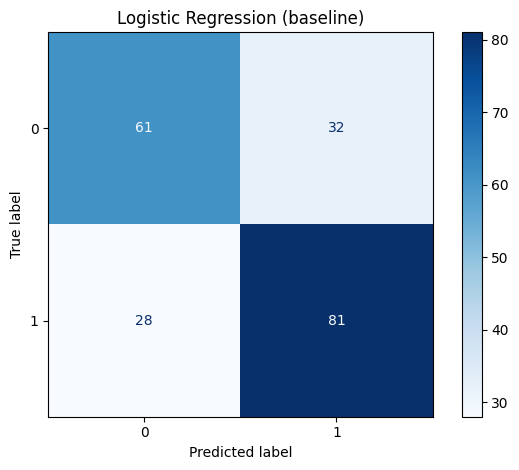

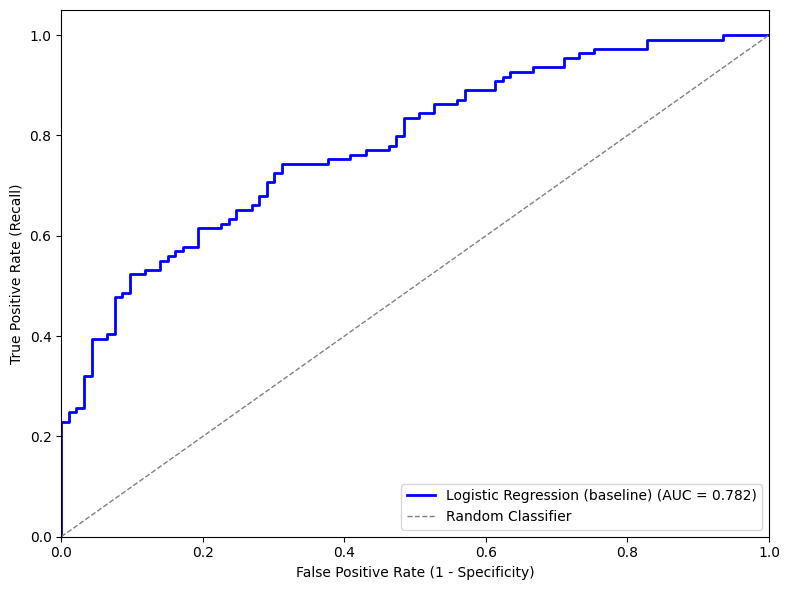

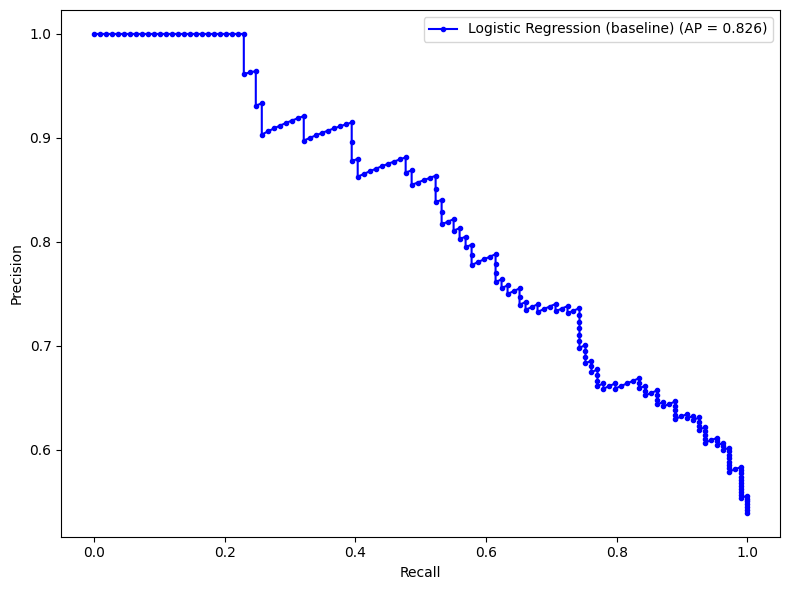

{'accuracy': 0.7029702970297029,
 'roc_auc': 0.7820854296142844,
 'log_loss': 0.5593229176861102,
 'brier': 0.1927634030478289}

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Same train/test split is reused throughout this section.
X_train, X_test, y_train, y_test = data.split_xy(df)

logreg_basic = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=10000, class_weight="balanced")),
])
logreg_basic.fit(X_train, y_train)

y_pred  = logreg_basic.predict(X_test)
y_proba = logreg_basic.predict_proba(X_test)[:, 1]
ev.evaluate("Logistic Regression (baseline)", y_test, y_pred, y_proba)

A quick check of how the split and class weighting affect the baseline
(accuracy / ROC AUC on the test set):

| stratify | class_weight | accuracy | ROC AUC |
|----------|--------------|----------|---------|
| off | off | 0.703 | 0.760 |
| off | on  | 0.668 | 0.760 |
| on  | off | 0.678 | 0.782 |
| on  | on  | 0.703 | 0.782 |

Class weighting moves accuracy around but leaves AUC untouched, since it only
shifts the decision threshold, not the ranking of predictions.

### Tuned with cross-validation

Grid search over `C`, penalty (L1/L2) and a few other settings. L1 is worth a
close look because it performs feature selection: it drives some coefficients
to exactly zero, so the final model is smaller and easier to interpret.

Fitting 5 folds for each of 208 candidates, totalling 1040 fits
Best parameters: {'logreg__C': 0.05, 'logreg__fit_intercept': True, 'logreg__max_iter': 1000, 'logreg__penalty': 'l1'}
Best CV ROC AUC: 0.7923
=== Logistic Regression (tuned) ===
Accuracy:     0.7327
ROC AUC:      0.8011
Log Loss:     0.548
Brier Score:  0.1849
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.71      0.71        93
           1       0.75      0.75      0.75       109

    accuracy                           0.73       202
   macro avg       0.73      0.73      0.73       202
weighted avg       0.73      0.73      0.73       202



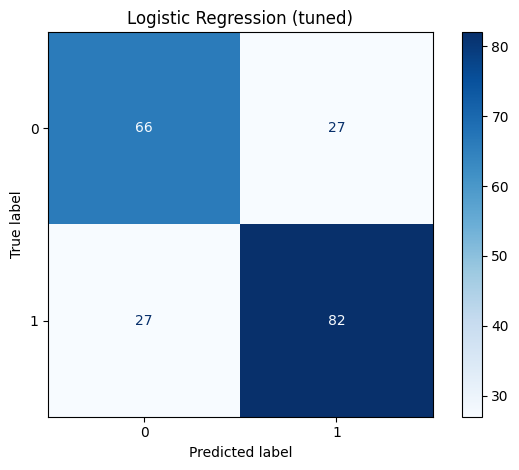

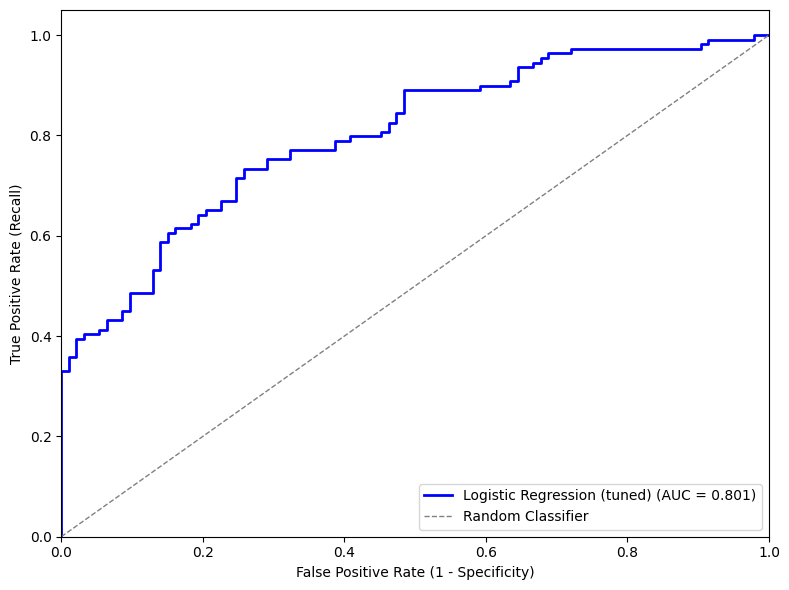

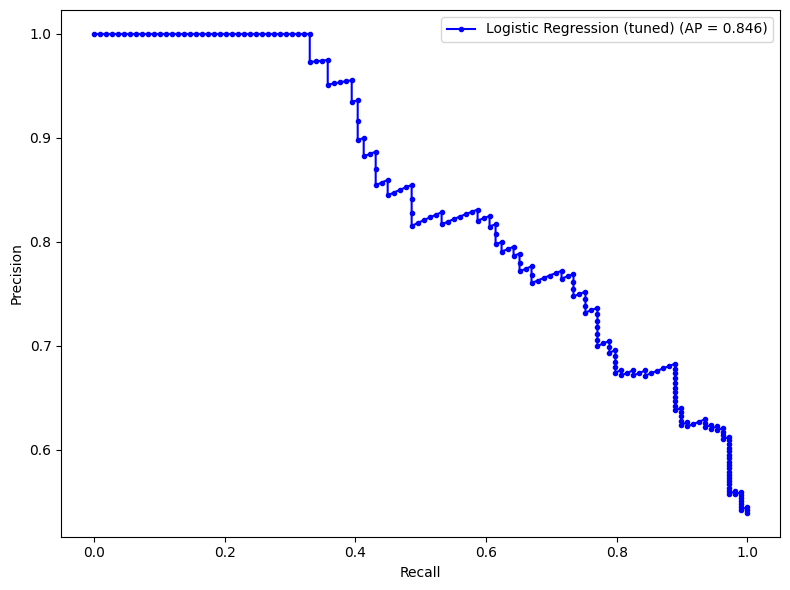

L1 kept 17 of 142 features (125 dropped).


In [5]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    # 'liblinear' supports L1 and works well on small datasets.
    ("logreg", LogisticRegression(solver="liblinear", class_weight="balanced")),
])

param_grid = {
    "logreg__penalty": ["l1", "l2"],
    "logreg__C": [1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000],
    "logreg__fit_intercept": [True, False],
    "logreg__max_iter": [1000, 5000, 10000, 15000],
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="roc_auc",
                    n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC AUC:", round(grid.best_score_, 4))

logreg_best = grid.best_estimator_
ev.evaluate("Logistic Regression (tuned)", y_test,
            logreg_best.predict(X_test),
            logreg_best.predict_proba(X_test)[:, 1])

# How many features did L1 keep?
coefs = logreg_best.named_steps["logreg"].coef_[0]
n_zero = (coefs == 0).sum()
print(f"L1 kept {len(coefs) - n_zero} of {len(coefs)} features "
      f"({n_zero} dropped).")

### Baseline vs tuned

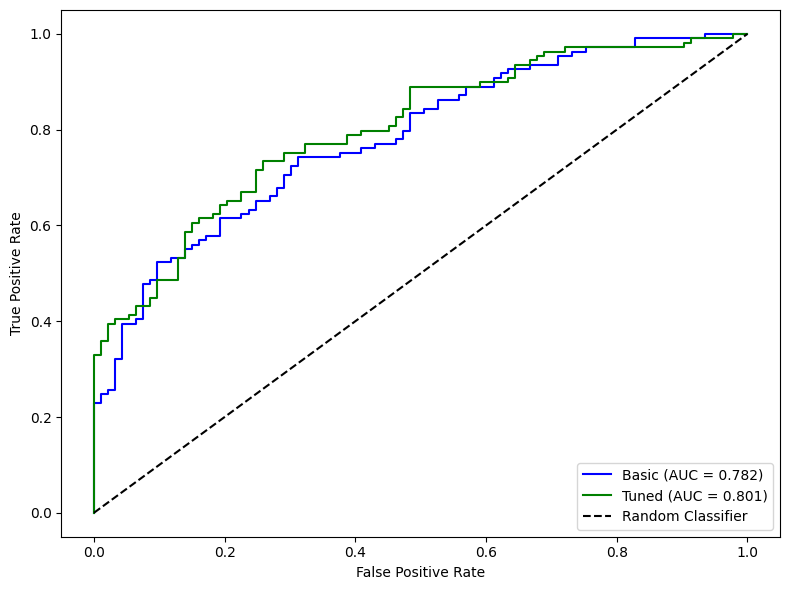

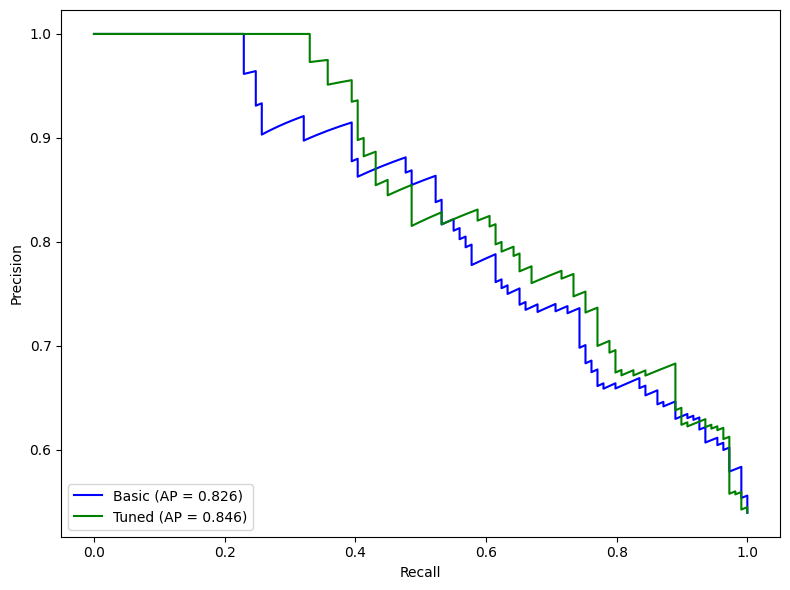

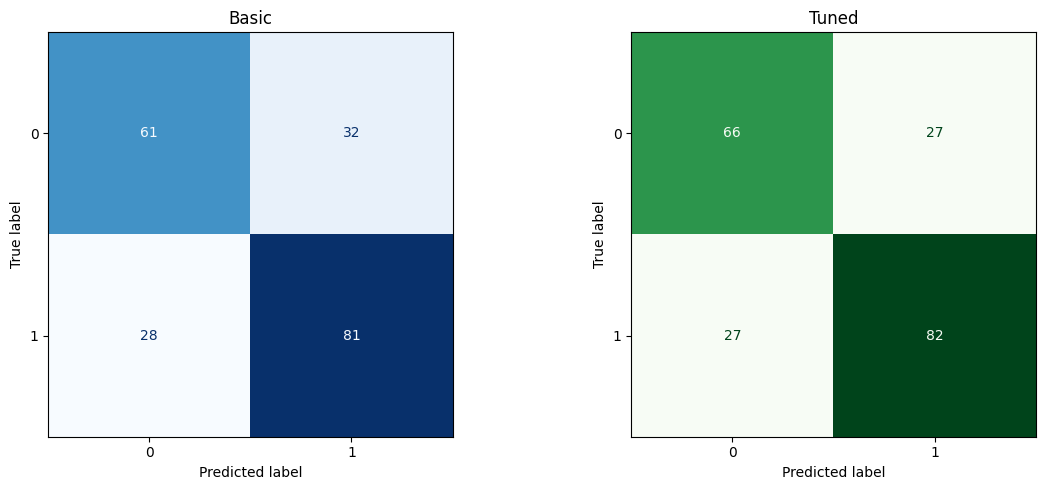

In [6]:
ev.compare_models(y_test, {
    "Basic": (logreg_basic.predict(X_test),
              logreg_basic.predict_proba(X_test)[:, 1]),
    "Tuned": (logreg_best.predict(X_test),
              logreg_best.predict_proba(X_test)[:, 1]),
})

### Which features matter most? (L1 coefficients)

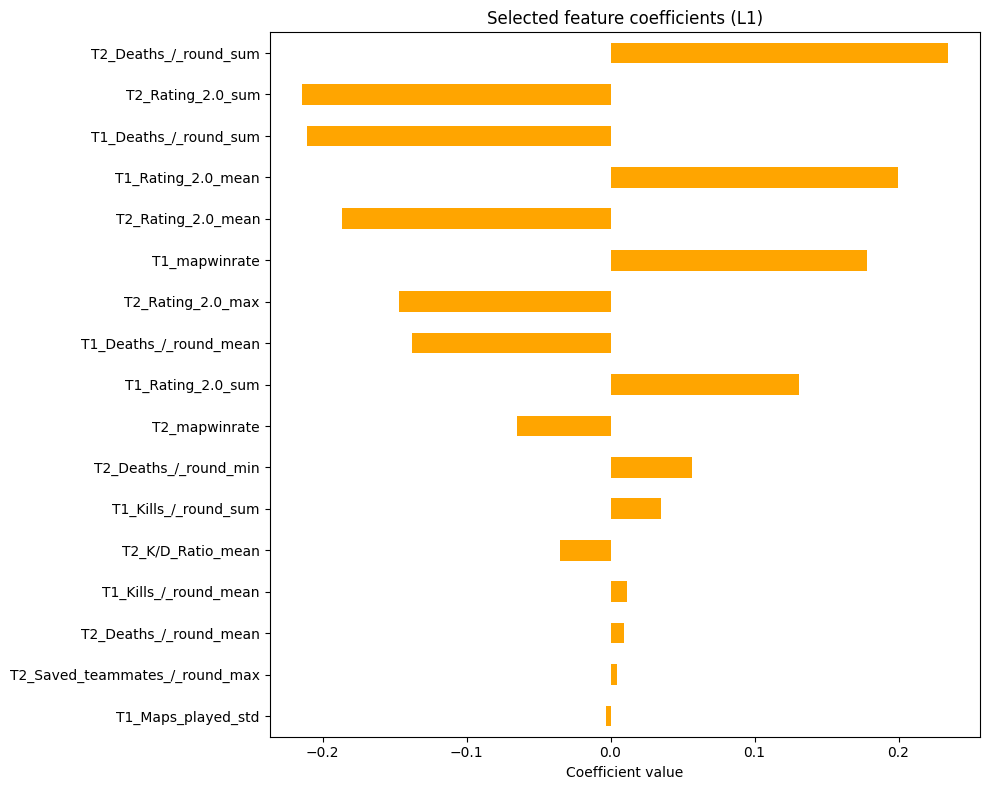

In [7]:
coef_series = pd.Series(logreg_best.named_steps["logreg"].coef_[0],
                        index=X_train.columns)
selected = coef_series[coef_series != 0].sort_values(key=abs, ascending=False)

selected.plot(kind="barh", figsize=(10, 8), color="orange",
              title="Selected feature coefficients (L1)")
plt.gca().invert_yaxis()
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

## 4. TabPFN

TabPFN is a transformer-based model pre-trained to classify small tabular
datasets without any hyperparameter tuning. It runs much faster on a GPU; the
cell below picks one up automatically if available and falls back to CPU
otherwise.

One caveat: this version of TabPFN accepts at most 100 features, and the table
here has 142. Passing `subsample_features=True` lets it run anyway by sampling
100 features internally. It prints a one-line message saying the features will
be subsampled, which is expected and not an error. The 100-feature limit is
also why the report experiments with smaller, hand-picked feature sets.

TabPFN was also evaluated on reduced feature sets selected by L1 logistic
regression, XGBoost and LightGBM importance; see the report for those results.

Using device: cpu


=== TabPFN ===
Accuracy:     0.6881
ROC AUC:      0.7956
Log Loss:     0.5468
Brier Score:  0.1876
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.59      0.64        93
           1       0.69      0.77      0.73       109

    accuracy                           0.69       202
   macro avg       0.69      0.68      0.68       202
weighted avg       0.69      0.69      0.69       202



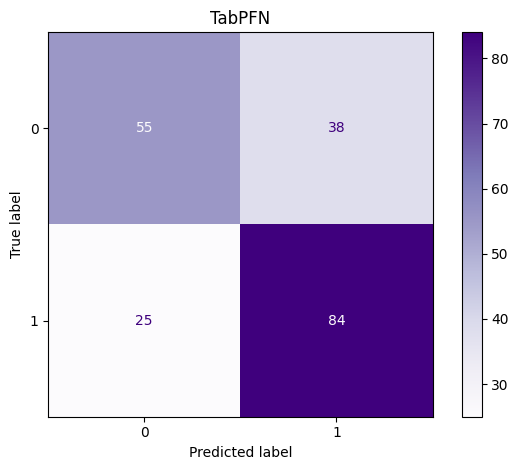

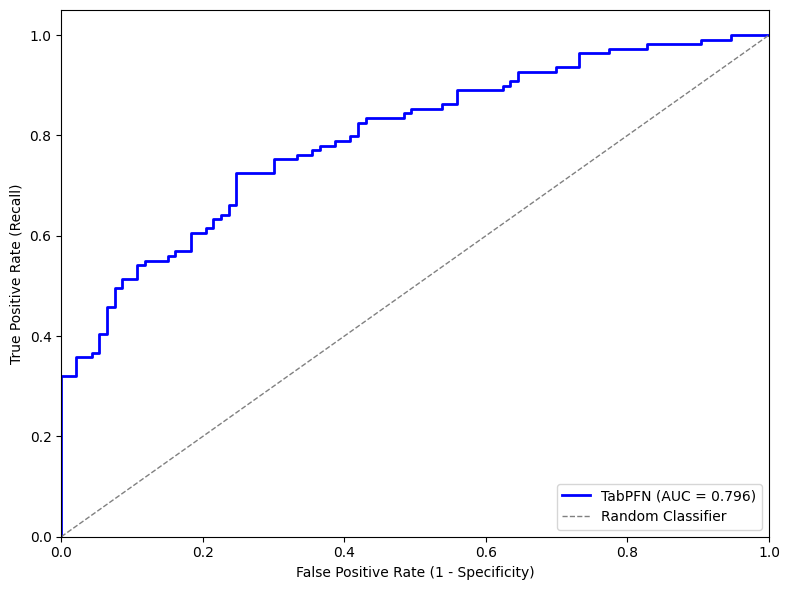

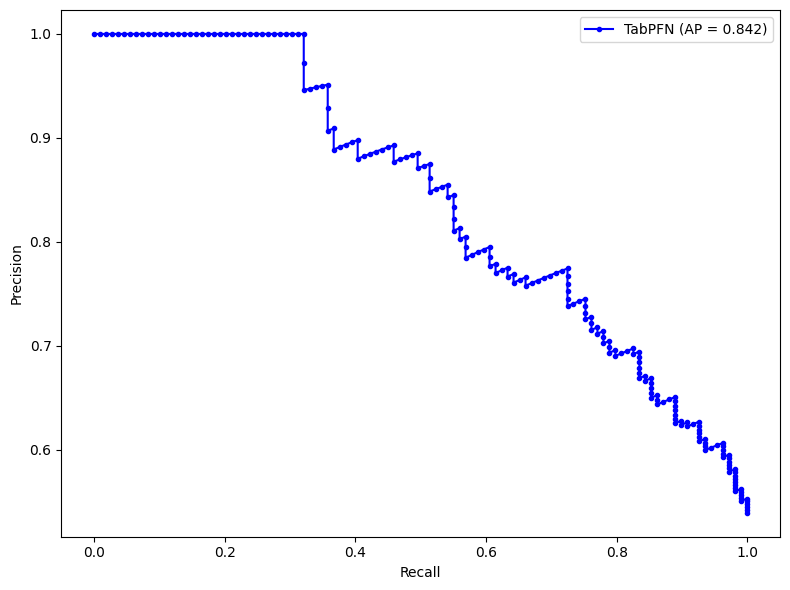

{'accuracy': 0.6881188118811881,
 'roc_auc': 0.7956002762158431,
 'log_loss': 0.5468320311744244,
 'brier': 0.18758524867807003}

In [8]:
import torch
from tabpfn import TabPFNClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

X_train, X_test, y_train, y_test = data.split_xy(df)

tabpfn = TabPFNClassifier(device=device, subsample_features=True)
tabpfn.fit(X_train, y_train)

y_pred  = tabpfn.predict(X_test)
y_proba = tabpfn.predict_proba(X_test)[:, 1]
ev.evaluate("TabPFN", y_test, y_pred, y_proba, cmap="Purples")

### Classification-threshold tuning

By default a match is predicted as a team-1 win when the predicted probability
is at least 0.5. Sweeping that threshold shows how accuracy trades off around
the default. Since the sweep uses the test set, the "best" threshold printed
below is optimistic; it illustrates the trade-off rather than giving a tuned
parameter.

Best threshold for accuracy: 0.57 (accuracy 0.728)


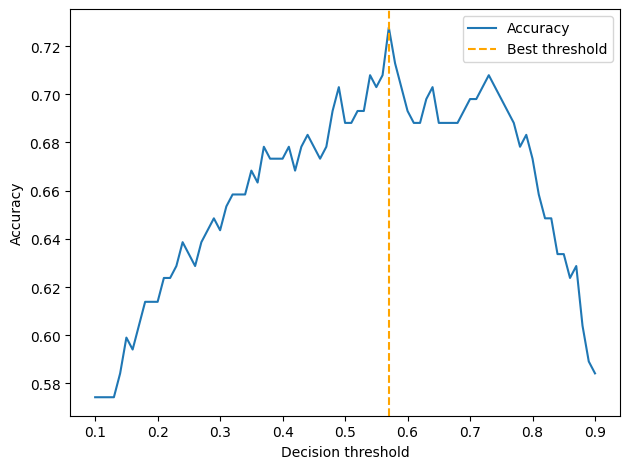

In [9]:
from sklearn.metrics import accuracy_score

y_proba = tabpfn.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.1, 0.9, 81)
accuracies = [accuracy_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]

best_i = int(np.argmax(accuracies))
print(f"Best threshold for accuracy: {thresholds[best_i]:.2f} "
      f"(accuracy {accuracies[best_i]:.3f})")

plt.figure()
plt.plot(thresholds, accuracies, label="Accuracy")
plt.axvline(thresholds[best_i], color="orange", linestyle="--",
            label="Best threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 5. XGBoost

A gradient-boosted tree model. We look at a baseline, its feature importances,
a tuned version, and a pruned version that drops low-importance features.

=== XGBoost (baseline) ===
Accuracy:     0.7475
ROC AUC:      0.8093
Log Loss:     0.5454
Brier Score:  0.1819
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.70      0.72        93
           1       0.75      0.79      0.77       109

    accuracy                           0.75       202
   macro avg       0.75      0.74      0.74       202
weighted avg       0.75      0.75      0.75       202



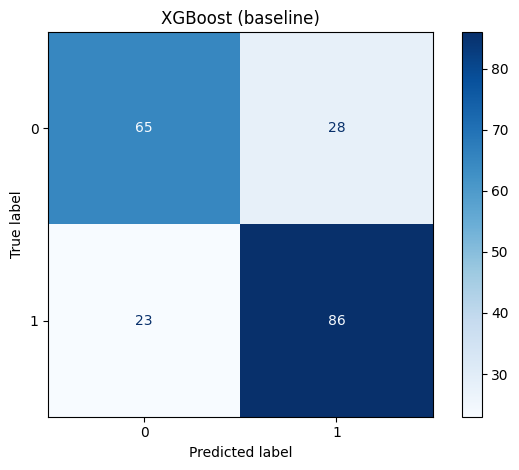

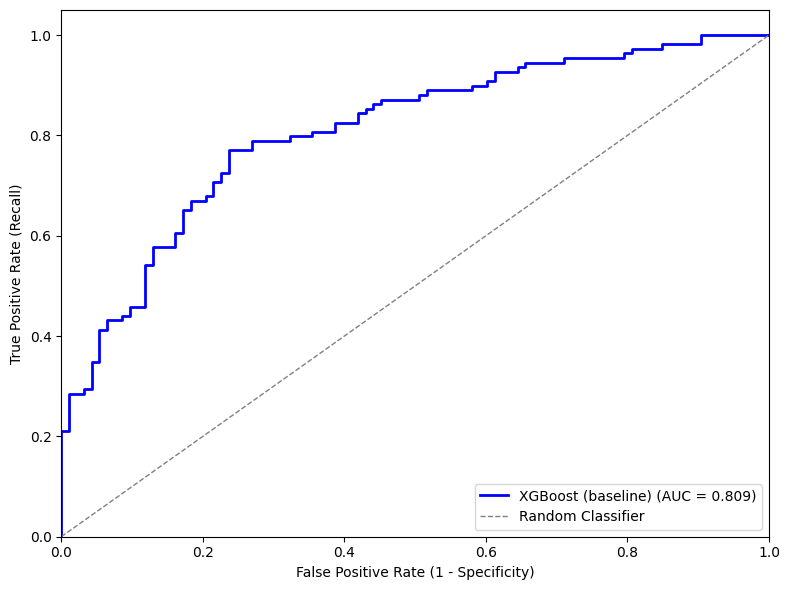

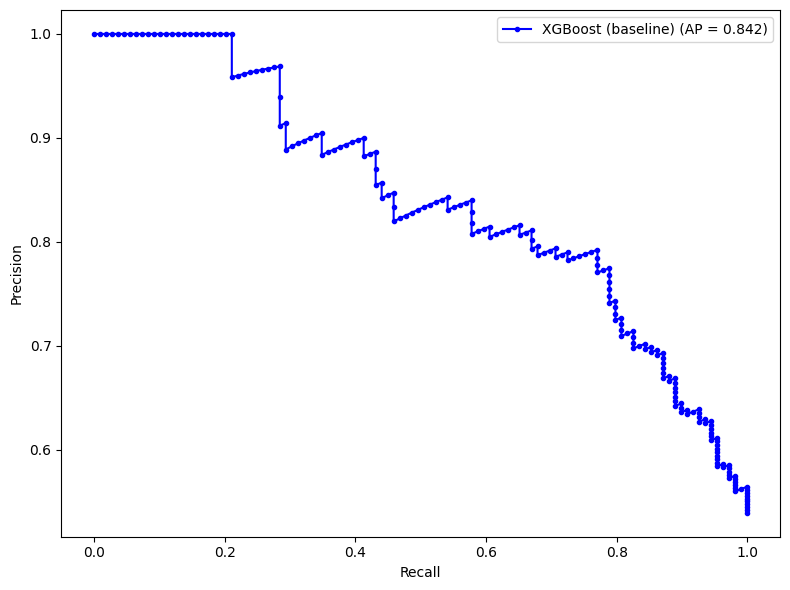

{'accuracy': 0.7475247524752475,
 'roc_auc': 0.8093124198480813,
 'log_loss': 0.5454035346162764,
 'brier': 0.18191111862979845}

In [10]:
from xgboost import XGBClassifier
import xgboost as xgb

X_train, X_test, y_train, y_test = data.split_xy(df)

xgb_basic = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                          eval_metric="logloss")
xgb_basic.fit(X_train, y_train)
ev.evaluate("XGBoost (baseline)", y_test,
            xgb_basic.predict(X_test),
            xgb_basic.predict_proba(X_test)[:, 1])

### Feature importance (by gain)

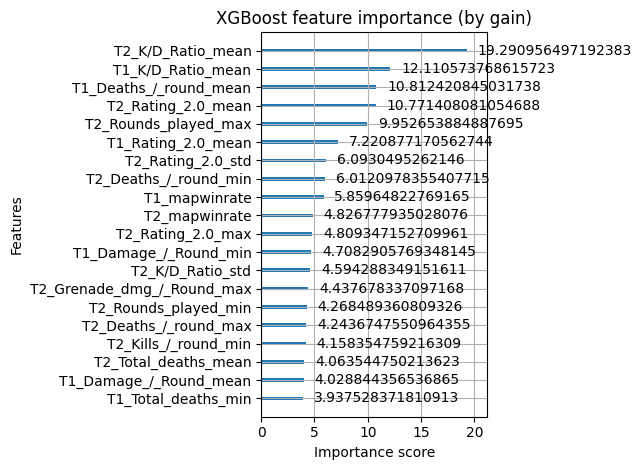

In [11]:
xgb.plot_importance(xgb_basic, importance_type="gain", max_num_features=20)
plt.title("XGBoost feature importance (by gain)")
plt.tight_layout()
plt.show()

### SHAP values  *(optional, requires `pip install shap`)*

SHAP explains how each feature pushes individual predictions up or down.

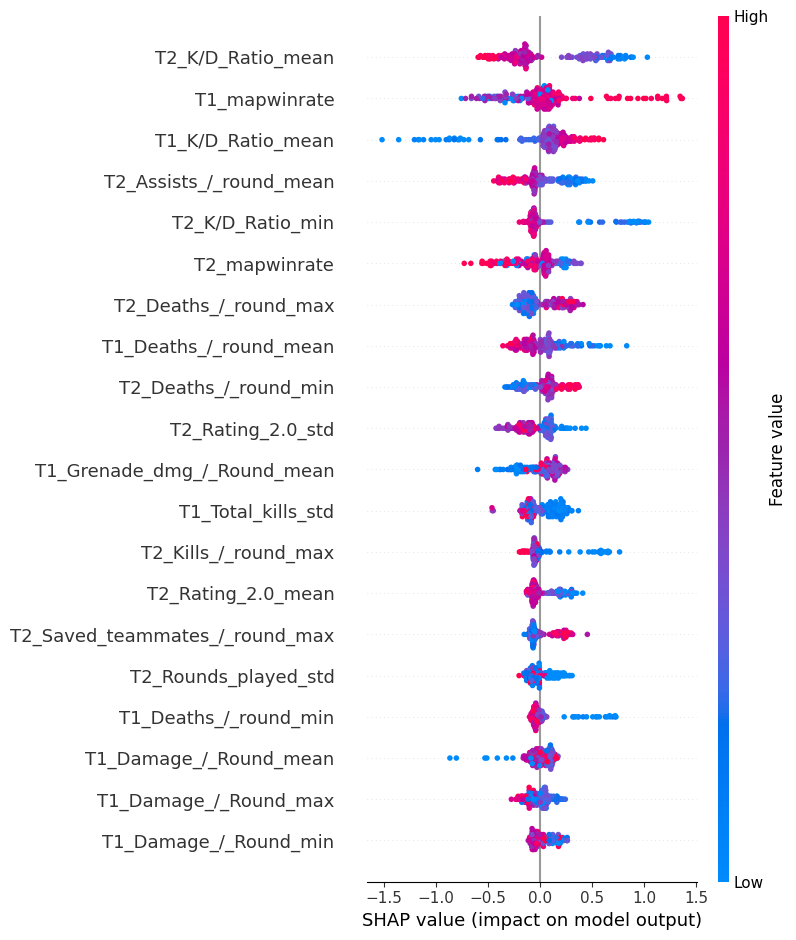

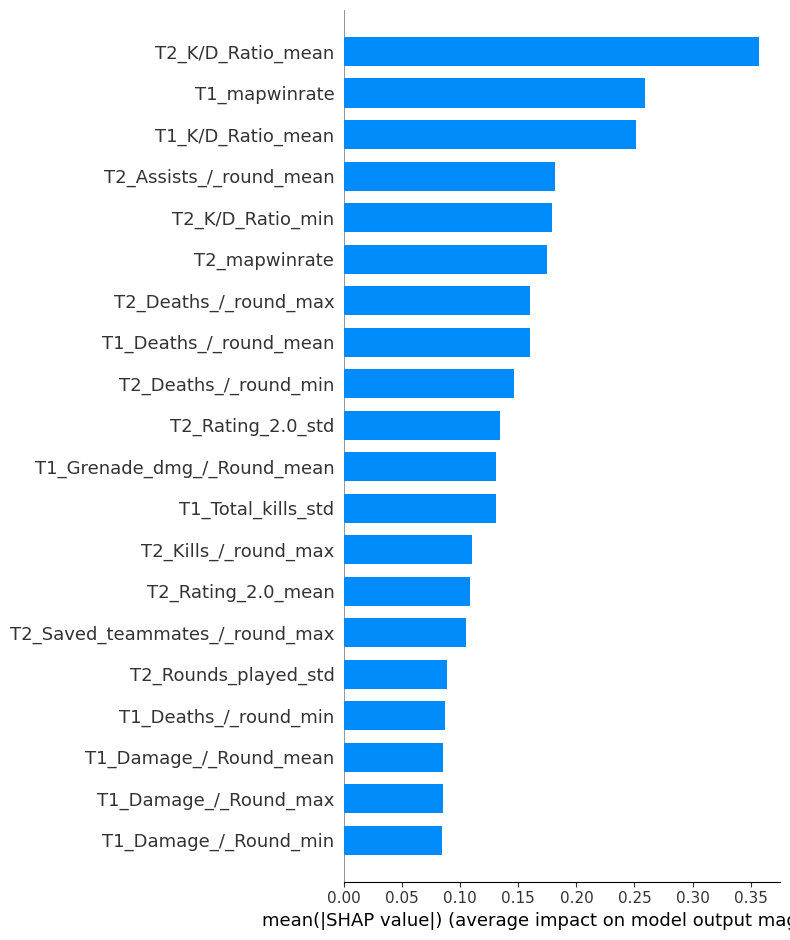

In [12]:
import shap

explainer = shap.Explainer(xgb_basic)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dot")
shap.summary_plot(shap_values, X_test, plot_type="bar")

### Tuned (cross-validation) + pruning low-importance features

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'clf__colsample_bytree': 1.0, 'clf__gamma': 1, 'clf__learning_rate': 0.01, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Best CV ROC AUC: 0.7977
=== XGBoost (tuned) ===
Accuracy:     0.7327
ROC AUC:      0.8154
Log Loss:     0.536
Brier Score:  0.1797
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.65      0.69        93
           1       0.73      0.81      0.77       109

    accuracy                           0.73       202
   macro avg       0.73      0.73      0.73       202
weighted avg       0.73      0.73      0.73       202



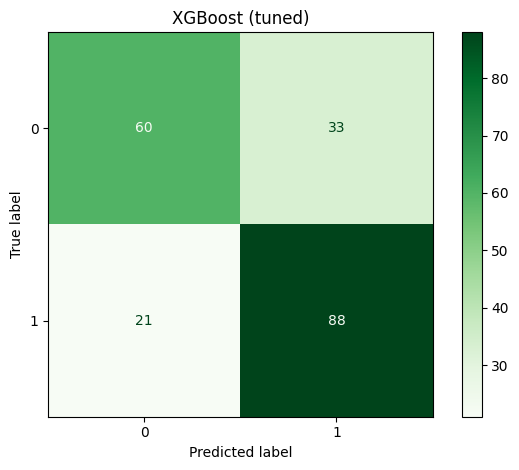

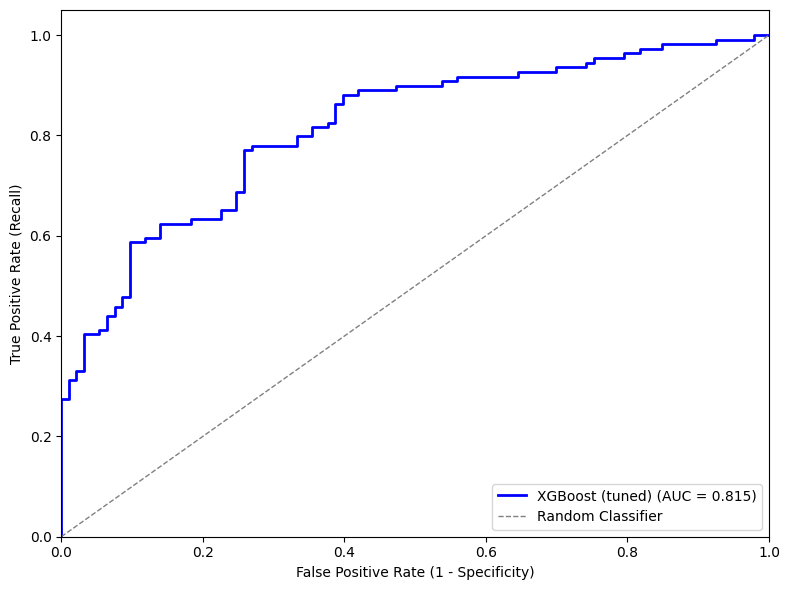

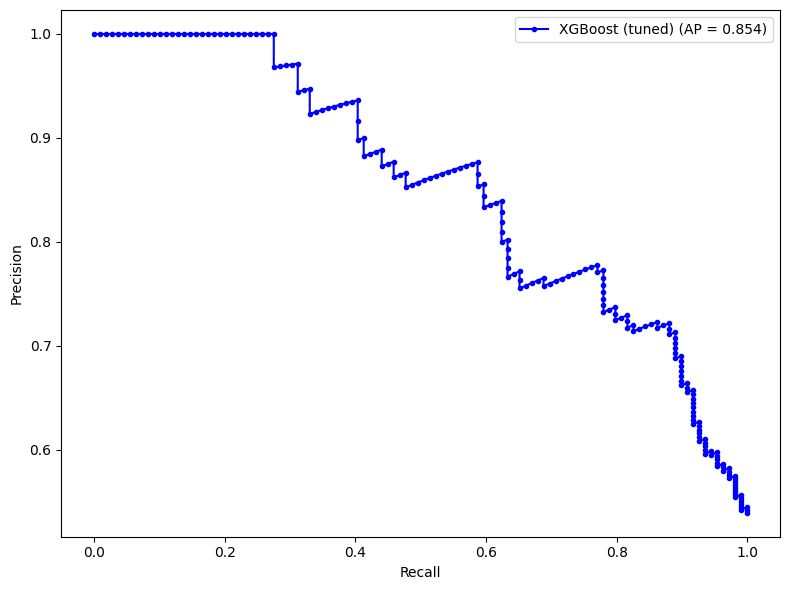

Dropping 125 low-importance features.
=== XGBoost (pruned) ===
Accuracy:     0.7426
ROC AUC:      0.8262
Log Loss:     0.5239
Brier Score:  0.1748
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.65      0.70        93
           1       0.73      0.83      0.78       109

    accuracy                           0.74       202
   macro avg       0.75      0.74      0.74       202
weighted avg       0.74      0.74      0.74       202



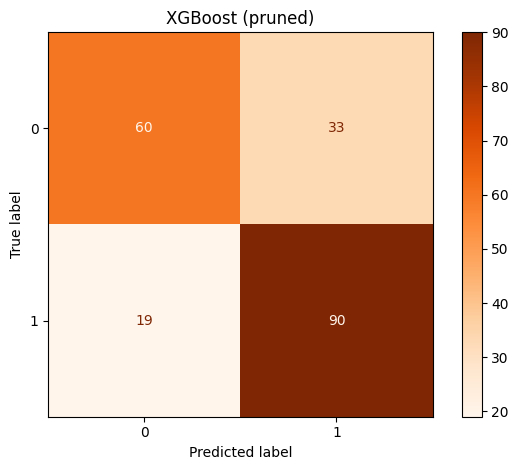

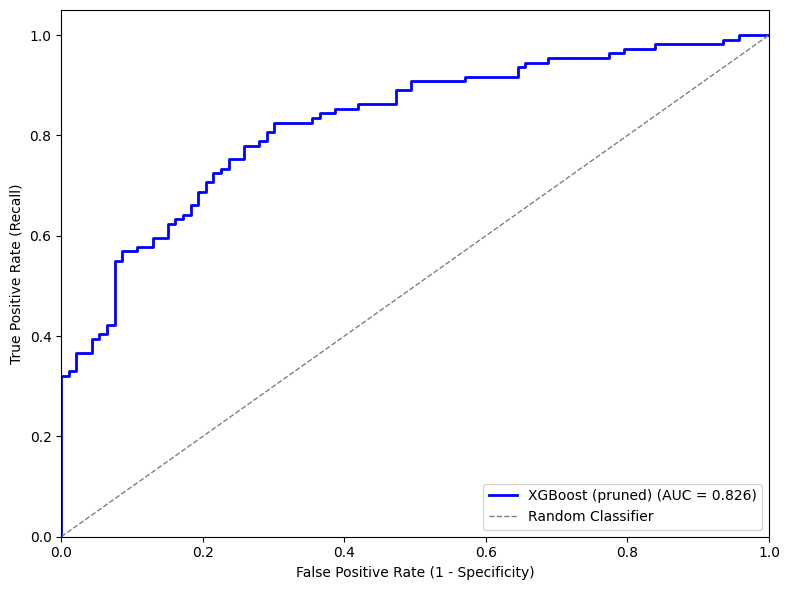

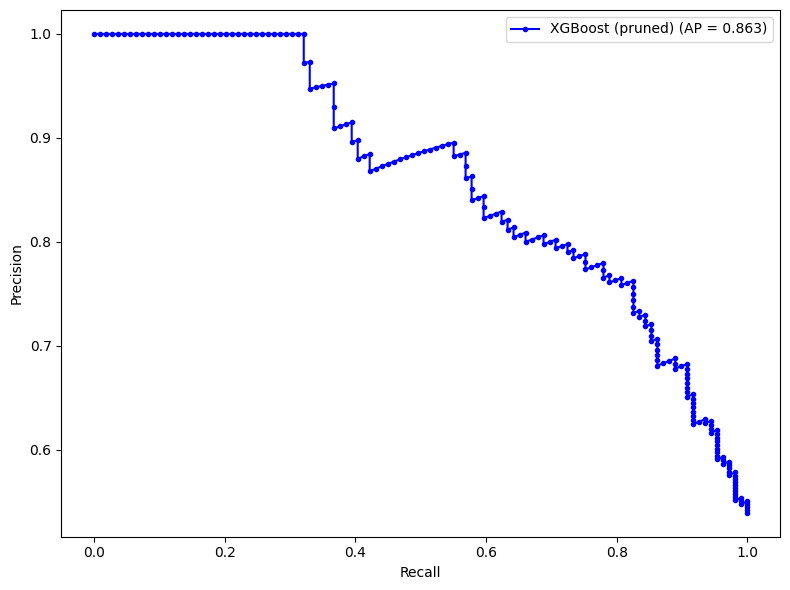

{'accuracy': 0.7425742574257426,
 'roc_auc': 0.8261813159711946,
 'log_loss': 0.5239140965815582,
 'brier': 0.17478299861193475}

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline = Pipeline([
    ("scaler", StandardScaler()),          # harmless for trees; kept for consistency
    ("clf", XGBClassifier(eval_metric="logloss")),
])
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.01, 0.1, 0.3],
    "clf__max_depth": [3, 4, 5],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__gamma": [0, 1],
}

grid = GridSearchCV(pipeline, param_grid, scoring="roc_auc", cv=cv,
                    n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV ROC AUC:", round(grid.best_score_, 4))

xgb_tuned = grid.best_estimator_
ev.evaluate("XGBoost (tuned)", y_test,
            xgb_tuned.predict(X_test),
            xgb_tuned.predict_proba(X_test)[:, 1], cmap="Greens")

# --- prune features with negligible permutation importance, then retrain ---
perm = permutation_importance(xgb_tuned, X_test, y_test, scoring="roc_auc",
                              n_repeats=5, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({"feature": X_train.columns,
                        "importance": perm.importances_mean})
drop = perm_df[perm_df["importance"] < 0.001]["feature"].tolist()
print(f"Dropping {len(drop)} low-importance features.")

X_train_r = X_train.drop(columns=drop)
X_test_r  = X_test.drop(columns=drop)

bp = grid.best_params_
xgb_pruned = XGBClassifier(
    n_estimators=bp["clf__n_estimators"], learning_rate=bp["clf__learning_rate"],
    max_depth=bp["clf__max_depth"], subsample=bp["clf__subsample"],
    colsample_bytree=bp["clf__colsample_bytree"], gamma=bp["clf__gamma"],
    eval_metric="logloss",
)
xgb_pruned.fit(X_train_r, y_train)
ev.evaluate("XGBoost (pruned)", y_test,
            xgb_pruned.predict(X_test_r),
            xgb_pruned.predict_proba(X_test_r)[:, 1], cmap="Oranges")

### XGBoost: baseline vs tuned vs pruned

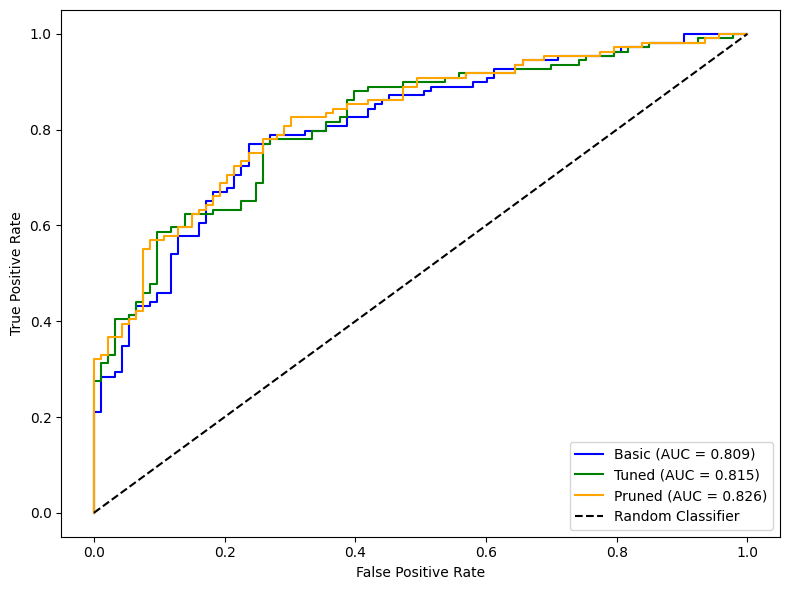

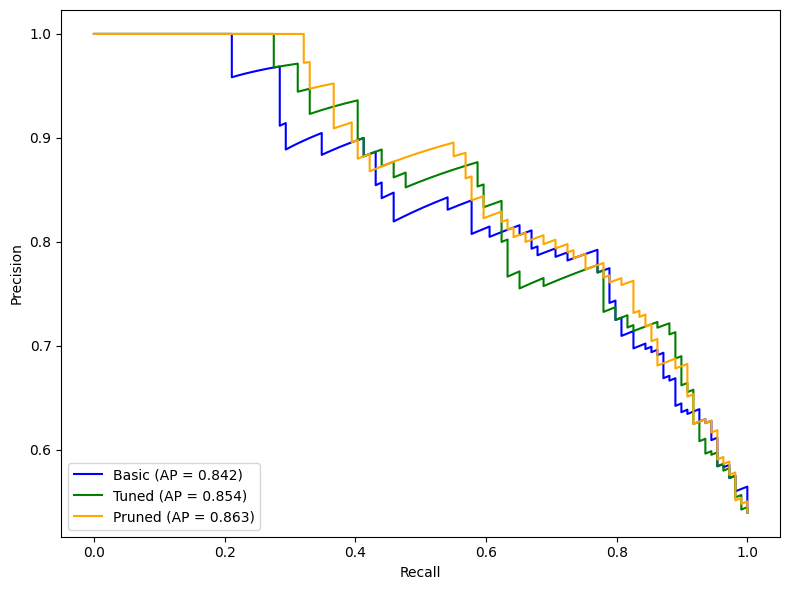

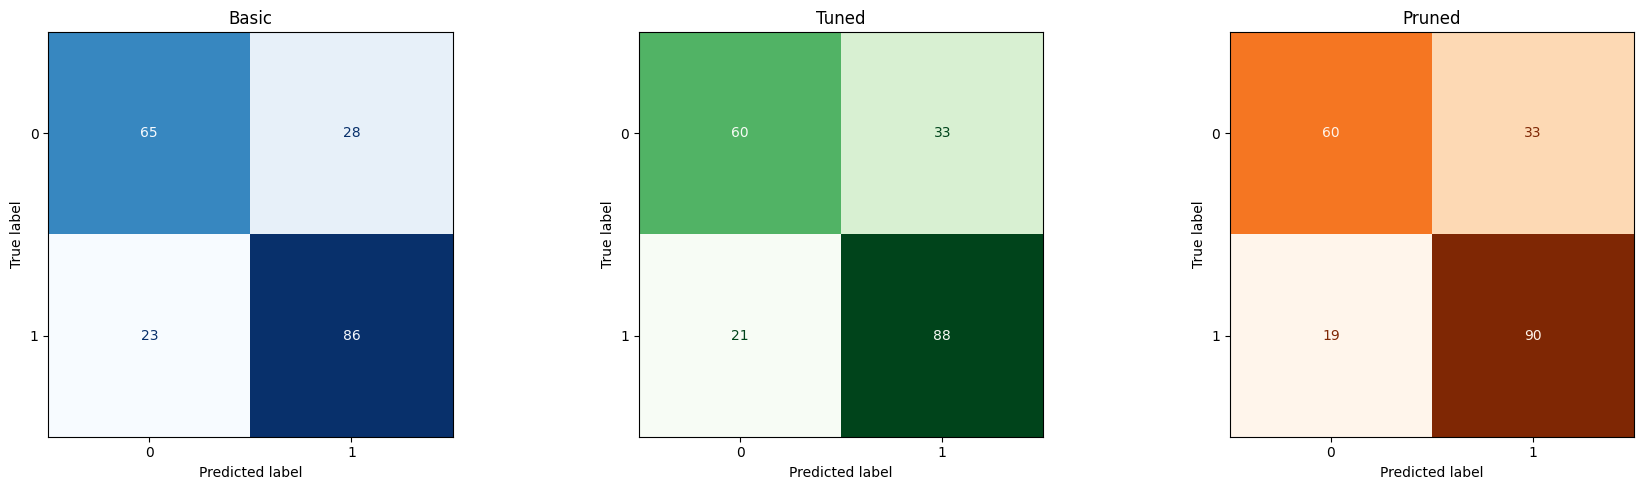

In [14]:
ev.compare_models(y_test, {
    "Basic":  (xgb_basic.predict(X_test),    xgb_basic.predict_proba(X_test)[:, 1]),
    "Tuned":  (xgb_tuned.predict(X_test),    xgb_tuned.predict_proba(X_test)[:, 1]),
    "Pruned": (xgb_pruned.predict(X_test_r), xgb_pruned.predict_proba(X_test_r)[:, 1]),
})

## 6. LightGBM

Another gradient-boosting library. Unlike the others, LightGBM can use `map`
directly as a categorical feature, so we keep it here.

=== LightGBM (baseline) ===
Accuracy:     0.7673
ROC AUC:      0.8134
Log Loss:     0.6506
Brier Score:  0.1883
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.72      0.74        93
           1       0.77      0.81      0.79       109

    accuracy                           0.77       202
   macro avg       0.77      0.76      0.76       202
weighted avg       0.77      0.77      0.77       202



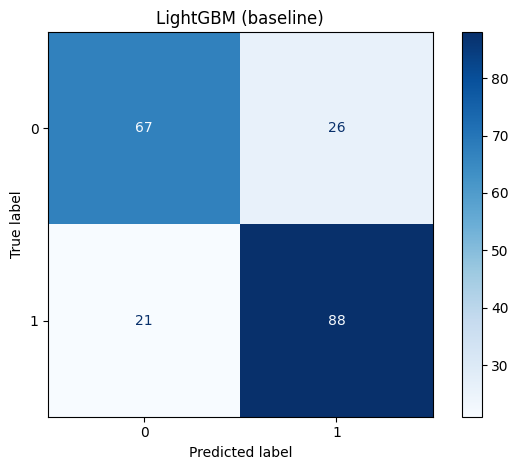

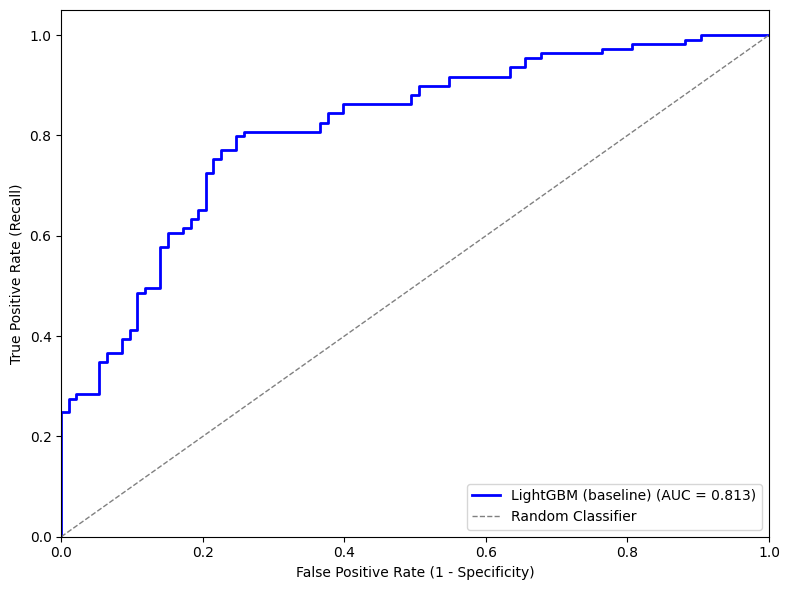

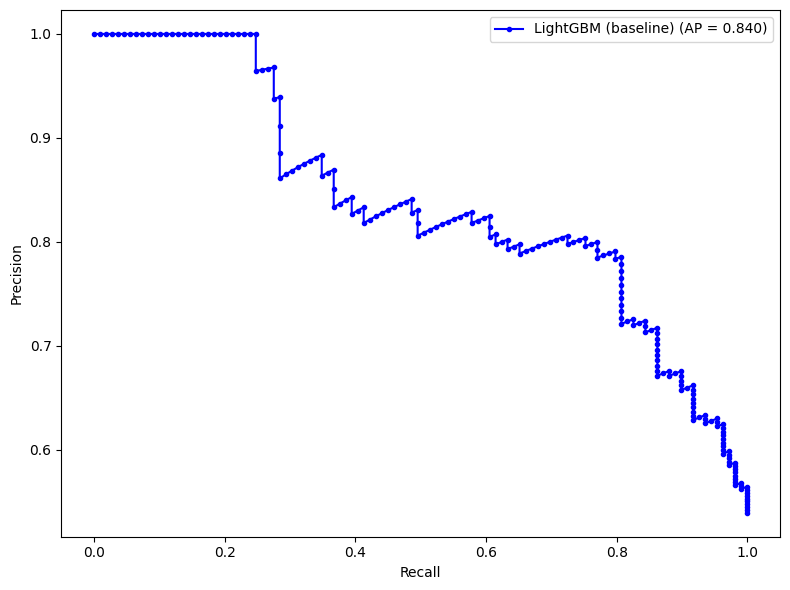

{'accuracy': 0.7673267326732673,
 'roc_auc': 0.8133570089770149,
 'log_loss': 0.6506202618239436,
 'brier': 0.188285791370791}

In [15]:
from lightgbm import LGBMClassifier

# Keep 'map' as a categorical feature for LightGBM.
df_lgb = df.copy()
df_lgb["map"] = df_lgb["map"].astype("category")

X_train, X_test, y_train, y_test = data.split_xy(df_lgb, keep_map=True)
X_train["map"] = X_train["map"].astype("category")
X_test["map"]  = X_test["map"].astype("category")

lgb_basic = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=7, num_leaves=40,
    min_data_in_leaf=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1, class_weight="balanced",
)
lgb_basic.fit(X_train, y_train, categorical_feature=["map"])
ev.evaluate("LightGBM (baseline)", y_test,
            lgb_basic.predict(X_test),
            lgb_basic.predict_proba(X_test)[:, 1])

### Tuned (randomized search)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV ROC AUC: 0.794
Best params: {'subsample': 0.8, 'num_leaves': 60, 'n_estimators': 300, 'min_data_in_leaf': 20, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
=== LightGBM (tuned) ===
Accuracy:     0.7376
ROC AUC:      0.8095
Log Loss:     0.5284
Brier Score:  0.1776
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72        93
           1       0.76      0.74      0.75       109

    accuracy                           0.74       202
   macro avg       0.74      0.74      0.74       202
weighted avg       0.74      0.74      0.74       202



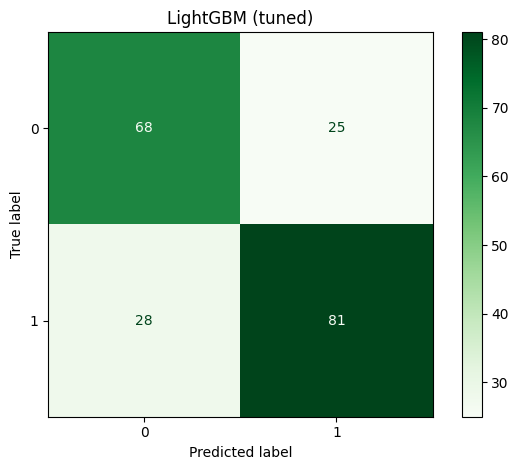

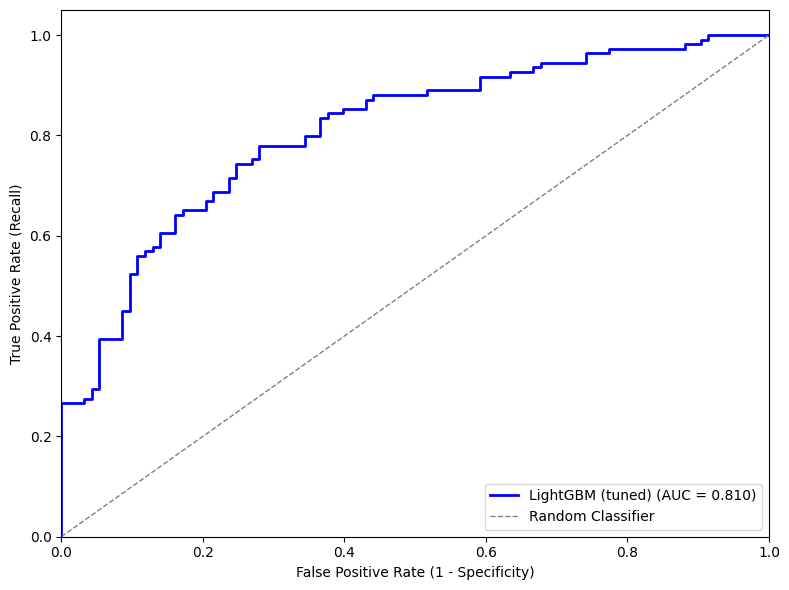

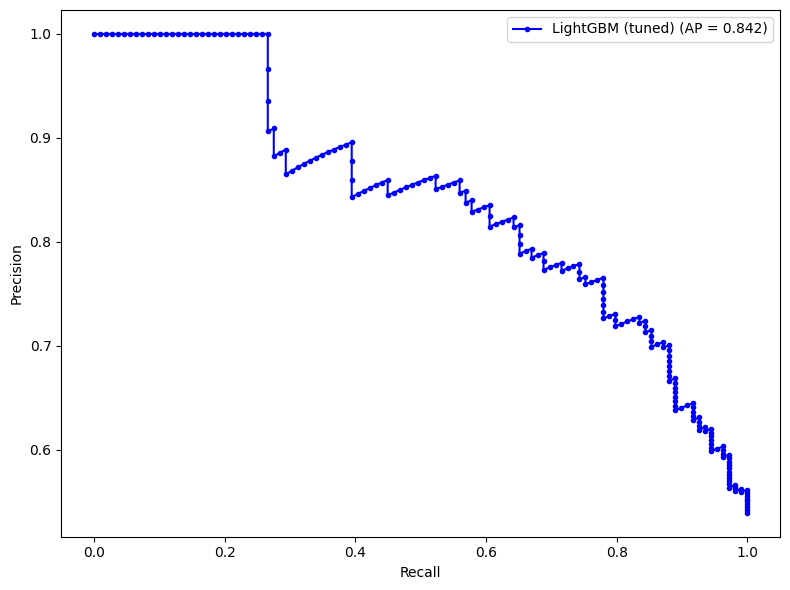

{'accuracy': 0.7376237623762376,
 'roc_auc': 0.809509716878761,
 'log_loss': 0.5284257026294221,
 'brier': 0.17761040510294626}

In [16]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

base = LGBMClassifier(objective="binary", random_state=42,
                      class_weight="balanced", verbose=-1)
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 7, 10, -1],
    "num_leaves": [20, 31, 40, 60],
    "min_data_in_leaf": [10, 15, 20, 30],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(base, param_dist, scoring="roc_auc", n_iter=30,
                            cv=cv, verbose=1, n_jobs=-1, random_state=42,
                            refit=True, error_score="raise")
search.fit(X_train, y_train, categorical_feature=["map"])

print("Best CV ROC AUC:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

lgb_tuned = search.best_estimator_
ev.evaluate("LightGBM (tuned)", y_test,
            lgb_tuned.predict(X_test),
            lgb_tuned.predict_proba(X_test)[:, 1], cmap="Greens")

### Permutation importance + pruned refit

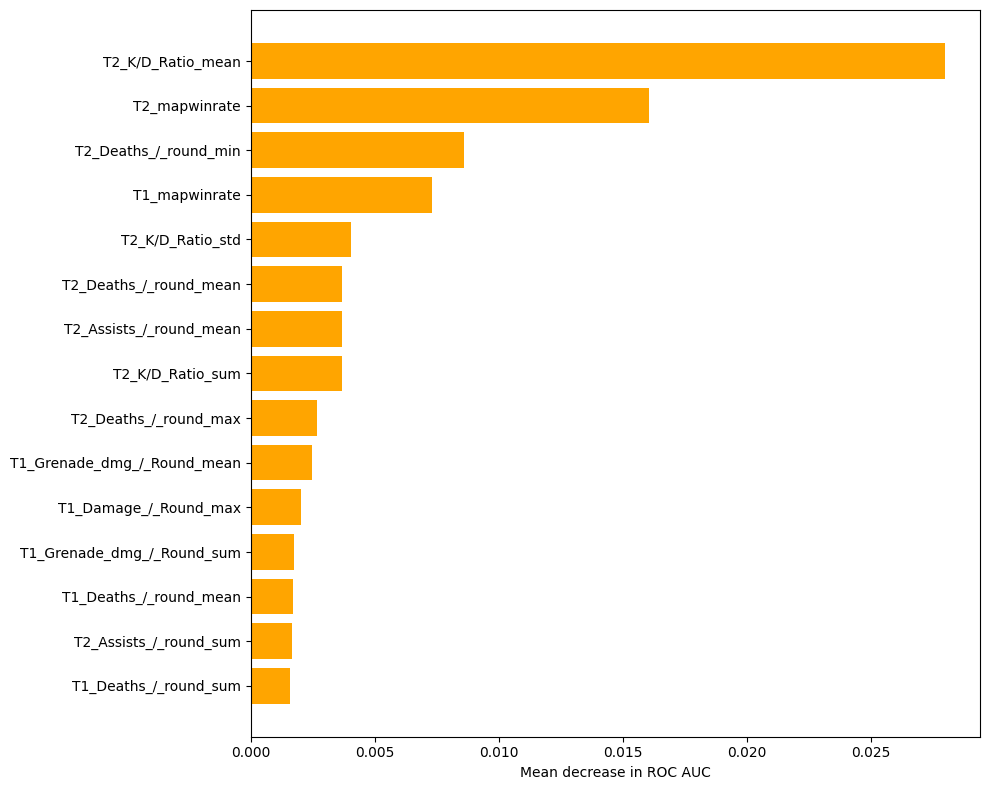

Retaining 19 features.
=== LightGBM (pruned) ===
Accuracy:     0.7525
ROC AUC:      0.8346
Log Loss:     0.4998
Brier Score:  0.1666
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.72      0.73        93
           1       0.77      0.78      0.77       109

    accuracy                           0.75       202
   macro avg       0.75      0.75      0.75       202
weighted avg       0.75      0.75      0.75       202



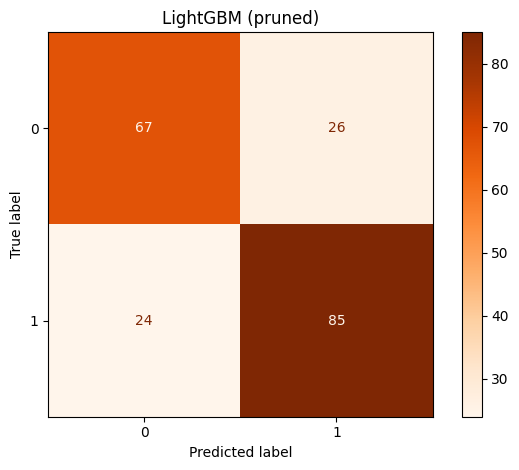

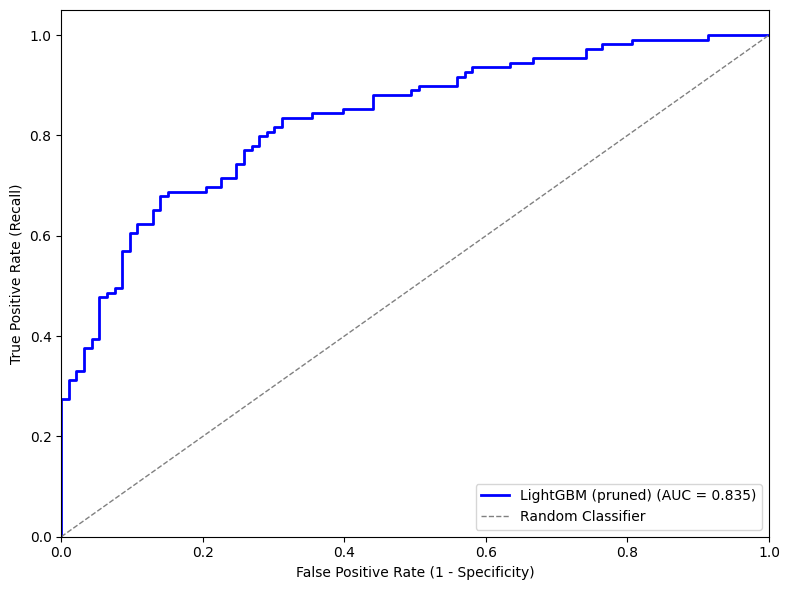

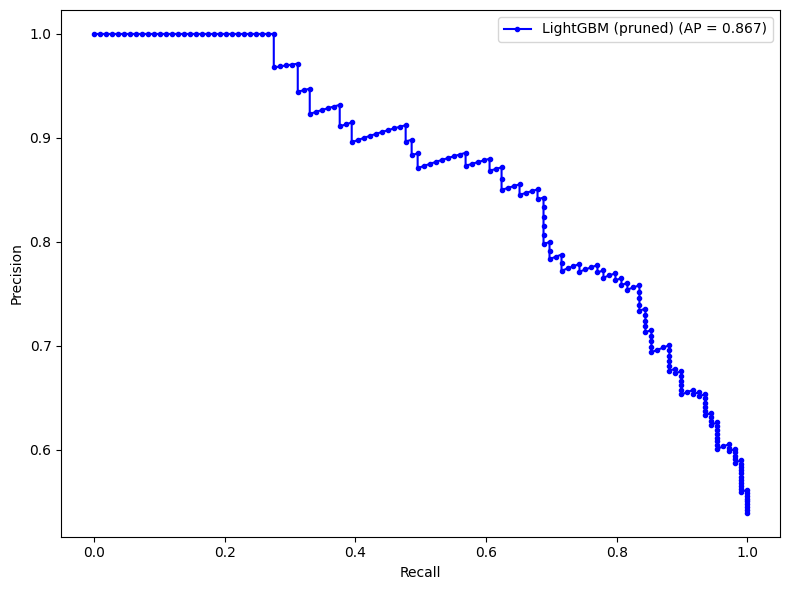

{'accuracy': 0.7524752475247525,
 'roc_auc': 0.8345664397750815,
 'log_loss': 0.499825732513259,
 'brier': 0.1666091250041047}

In [17]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(lgb_tuned, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=42, n_jobs=-1)
imp = pd.DataFrame({"feature": X_test.columns,
                    "importance": perm.importances_mean}).sort_values(
                        "importance", ascending=False)

top = imp.head(15)
plt.figure(figsize=(10, 8))
plt.barh(top["feature"], top["importance"], color="orange")
plt.xlabel("Mean decrease in ROC AUC")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Keep only features with meaningful importance, then refit.
useful = imp[imp["importance"] > 0.001]["feature"].tolist()
print(f"Retaining {len(useful)} features.")

X_train_r = X_train[useful].copy()
X_test_r  = X_test[useful].copy()
cat = ["map"] if "map" in useful else []
if cat:
    X_train_r["map"] = X_train_r["map"].astype("category")
    X_test_r["map"]  = X_test_r["map"].astype("category")

lgb_pruned = LGBMClassifier(**search.best_params_, objective="binary",
                            class_weight="balanced", random_state=42, verbose=-1)
lgb_pruned.fit(X_train_r, y_train, categorical_feature=cat)
ev.evaluate("LightGBM (pruned)", y_test,
            lgb_pruned.predict(X_test_r),
            lgb_pruned.predict_proba(X_test_r)[:, 1], cmap="Oranges")

### LightGBM: baseline vs tuned vs pruned

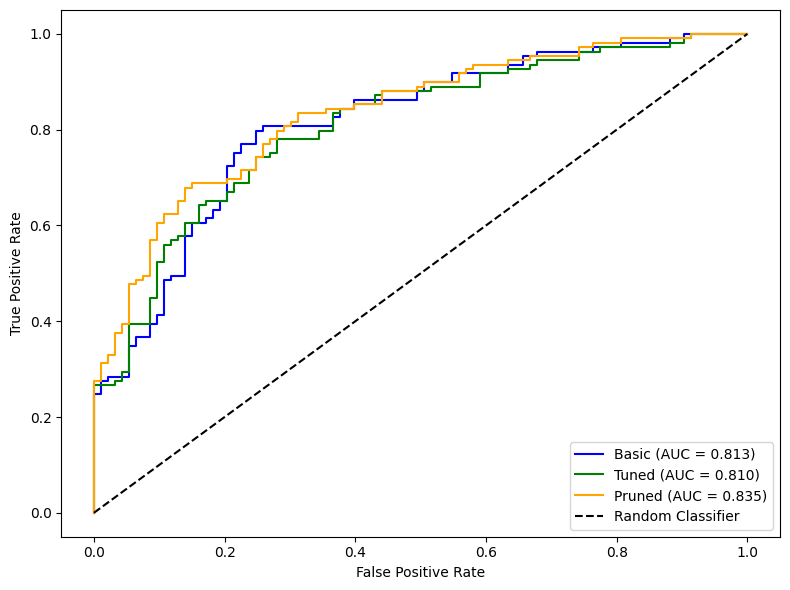

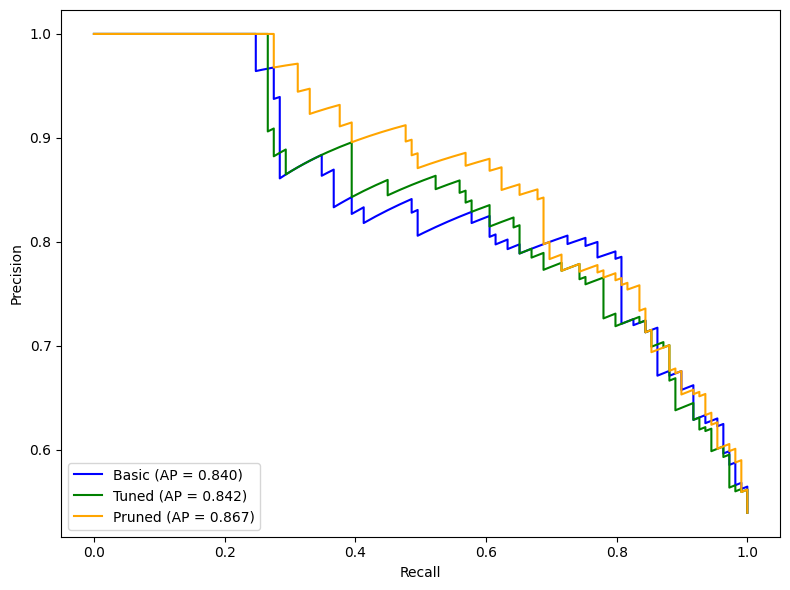

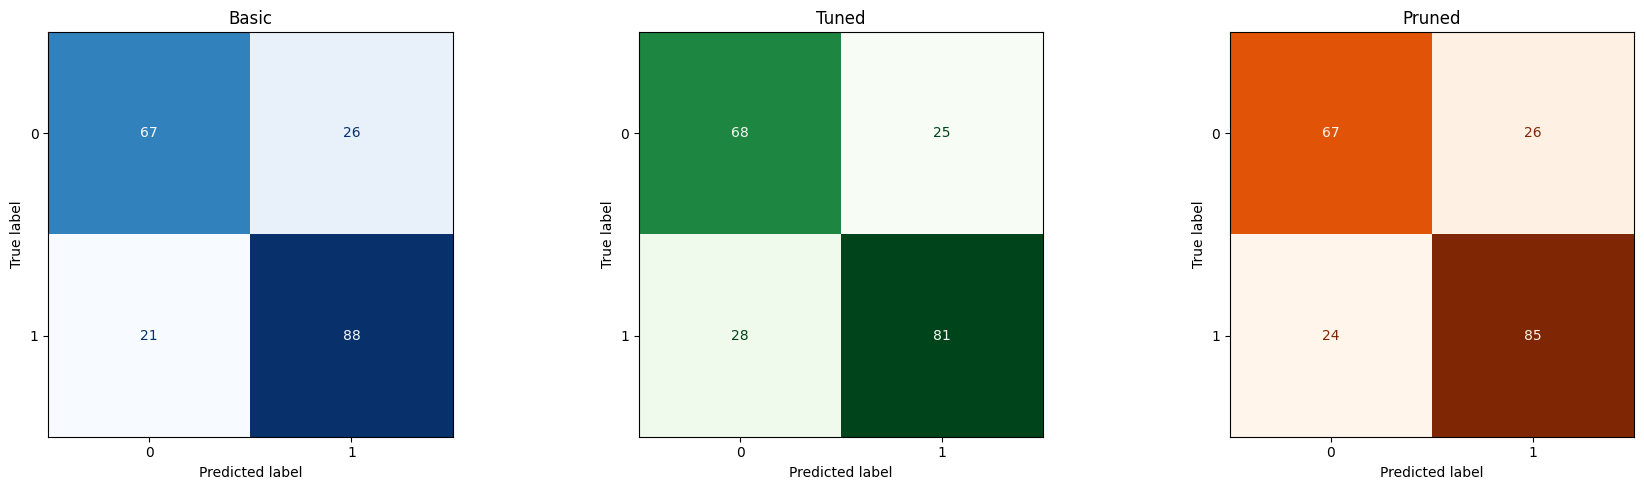

In [18]:
ev.compare_models(y_test, {
    "Basic":  (lgb_basic.predict(X_test),    lgb_basic.predict_proba(X_test)[:, 1]),
    "Tuned":  (lgb_tuned.predict(X_test),    lgb_tuned.predict_proba(X_test)[:, 1]),
    "Pruned": (lgb_pruned.predict(X_test_r), lgb_pruned.predict_proba(X_test_r)[:, 1]),
})

## 7. Takeaways

- The logistic regression results reproduce the report exactly: 70.3% accuracy
  / 0.782 AUC untuned, 73.3% / 0.801 tuned. Both sit above the 60-65% accuracy
  range reported in earlier CS:GO prediction studies.
- Results for the boosted trees depend on library versions, so the outputs
  above will not match the report digit for digit. The pattern holds either
  way: pruning low-importance features improves both tree models, and pruned
  LightGBM comes out on top (75.3% accuracy / 0.835 AUC in this run, 79.7% /
  0.862 in the report).
- TabPFN randomly subsamples 100 of the 142 features on every run, so its
  score moves around the most. In the report's runs it reached 73.3% accuracy
  with the best log-loss of the four models, with no tuning at all.
- The models broadly agree on which features matter: recent rating, deaths per
  round, K/D ratio and map win-rates.
- Two caveats: the dataset is small (1,010 matches from a three-month window),
  and the pruning step selects features using test-set permutation importance,
  so the pruned scores are likely somewhat optimistic.